# VWAP Trend Trading — Signal Research

**Paper:** Zarattini & Aziz (2024), "VWAP Trend Trading"
**Instrument:** QQQ (1-min bars, regular session 9:30–16:00 ET)
**Signal:** Close crosses cumulative daily VWAP → flip position
**Exit:** VWAP cross (flip) or EOD (15:55 ET)
**No stop loss** — exits only on VWAP cross or EOD.

This notebook generates raw signal trades — **no position sizing, no equity tracking.**

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time as dt_time
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [3]:
SYMBOL     = "QQQ"
INSTRUMENT = "QQQ"
START_DATE = "2016-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "VWAP Trend"
SAVE_NAME        = "vwap_trend"

RTH_START      = dt_time(9, 30)
RTH_FIRST_TRADE = dt_time(9, 31)  # paper says 9:31
RTH_END        = dt_time(15, 55)

## 3. Data Fetching & VWAP

In [4]:
data_dict = fetch_historical_data([SYMBOL], TimeFrame(1, TimeFrameUnit.Minute), START_DATE, END_DATE)
df = data_dict[SYMBOL].copy()
if df.index.tz is None:
    df.index = df.index.tz_localize("UTC").tz_convert("US/Eastern")
else:
    df.index = df.index.tz_convert("US/Eastern")

df = df.reset_index()
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

# RTH only
df = df[(df["time"] >= RTH_START) & (df["time"] < dt_time(16, 0))].copy()
df = df.sort_values("timestamp").reset_index(drop=True)

# Cumulative daily VWAP
df["hlc3"] = (df["high"] + df["low"] + df["close"]) / 3
df["hlc3_vol"] = df["hlc3"] * df["volume"]
df["cum_vol"] = df.groupby("date")["volume"].cumsum()
df["cum_hlc3_vol"] = df.groupby("date")["hlc3_vol"].cumsum()
df["daily_vwap"] = df["cum_hlc3_vol"] / df["cum_vol"]

print(f"RTH 1-min bars: {len(df):,}")
print(f"Trading days: {df['date'].nunique():,}")

Fetching QQQ...
  1,962,549 bars
RTH 1-min bars: 1,001,655
Trading days: 2,575


## 4. Signal Generation

In [5]:
def generate_signals(df):
    """
    Generate raw VWAP trend trades — signal only, no sizing.

    Logic: at 9:31, enter long if close > VWAP, short if close < VWAP.
    Flip when close crosses VWAP. Close all at 15:55 or EOD.

    Returns DataFrame with standardized columns.
    """
    trades = []

    for date, day_df in df.groupby("date"):
        day_df = day_df.sort_values("timestamp").reset_index(drop=True)

        if len(day_df) < 5:
            continue

        # First tradeable bar (9:31)
        first_bar_idx = 1
        if first_bar_idx >= len(day_df):
            continue

        first_bar = day_df.iloc[first_bar_idx]
        vwap_val = first_bar["daily_vwap"]
        if pd.isna(vwap_val) or vwap_val == 0:
            continue

        if first_bar["close"] > vwap_val:
            position = "long"
        elif first_bar["close"] < vwap_val:
            position = "short"
        else:
            continue

        entry_price = first_bar["close"]
        entry_time = first_bar["timestamp"]

        for i in range(first_bar_idx + 1, len(day_df)):
            bar = day_df.iloc[i]
            bar_close = bar["close"]
            bar_vwap = bar["daily_vwap"]

            if pd.isna(bar_vwap) or bar_vwap == 0:
                continue

            should_flip = False
            if position == "long" and bar_close < bar_vwap:
                should_flip = True
            elif position == "short" and bar_close > bar_vwap:
                should_flip = True

            is_last_bar = (i == len(day_df) - 1) or (bar["time"] >= RTH_END)

            if should_flip or is_last_bar:
                exit_price = bar_close

                if position == "long":
                    pct_ret = (exit_price - entry_price) / entry_price
                else:
                    pct_ret = (entry_price - exit_price) / entry_price

                trades.append({
                    "entry_time":      entry_time,
                    "exit_time":       bar["timestamp"],
                    "direction":       position,
                    "instrument":      INSTRUMENT,
                    "entry_price":     round(entry_price, 4),
                    "exit_price":      round(exit_price, 4),
                    "pct_return_gross": round(pct_ret, 6),
                    "exit_reason":     "eod" if is_last_bar else "vwap_cross",
                    "stop_price":      np.nan,
                })

                if should_flip and not is_last_bar:
                    position = "short" if position == "long" else "long"
                    entry_price = bar_close
                    entry_time = bar["timestamp"]
                else:
                    break

    return pd.DataFrame(trades)

print("generate_signals() defined.")

generate_signals() defined.


## 5. Signal Generation & Significance

## 6. Simple Equity Curve — Gross vs Net

In [11]:
raw_trades = generate_signals(df)
print(f"Total signal trades: {len(raw_trades)}")

# Net returns
raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"], slippage=0.0), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"Avg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# Significance: GROSS
sig_gross = raw_trades[["direction", "pct_return_gross"]].copy()
sig_gross["net_pnl"] = sig_gross["pct_return_gross"]
sig_gross["equity_before"] = 1.0
sig_gross["position"] = sig_gross["direction"]

if len(sig_gross) >= 5:
    report_gross = full_significance_report(sig_gross, strategy_name=f"{STRATEGY_NAME} (gross)")
    print_significance_report(report_gross)

# Significance: NET
sig_net = raw_trades[["direction", "pct_return_net"]].copy()
sig_net["net_pnl"] = sig_net["pct_return_net"]
sig_net["equity_before"] = 1.0
sig_net["position"] = sig_net["direction"]

if len(sig_net) >= 5:
    report_net = full_significance_report(sig_net, strategy_name=f"{STRATEGY_NAME} (net)")
    print_significance_report(report_net)

Total signal trades: 41289
Avg fee: 0.0029% per trade
Avg gross return: 0.0054%
Avg net return: 0.0025%

STATISTICAL SIGNIFICANCE — VWAP Trend (gross)

1. t-test (returns > 0)
   Mean return:  0.0054% per trade
   t-statistic:  4.0899
   p-value:      2.2e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.3195
   95% CI:            [0.1754, 0.4588]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.3195
   p-value:           0.0002
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)

STATISTICAL SIGNIFICANCE — VWAP Trend (net)

1. t-test (returns > 0)
   Mean return:  0.0025% per trade
   t-statistic:  1.9155
   p-value:      0.027716
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.1496
   95% CI:            [-0.0017, 0.2942]
   % below zero:      2.65%
   Significant:       NO



In [14]:
# CAGR: gross vs net
years = (pd.to_datetime(raw_trades["exit_time"].iloc[-1]) - pd.to_datetime(raw_trades["entry_time"].iloc[0])).days / 365.25

cum_gross = (1 + raw_trades["pct_return_gross"]).prod()
cum_net   = (1 + raw_trades["pct_return_net"]).prod()

cagr_gross = (cum_gross ** (1 / years) - 1) * 100
cagr_net   = (cum_net ** (1 / years) - 1) * 100

print(f"Gross: {(cum_gross-1)*100:.1f}% total, {cagr_gross:.1f}% CAGR")
print(f"Net:   {(cum_net-1)*100:.1f}% total, {cagr_net:.1f}% CAGR")

Gross: 695.6% total, 22.5% CAGR
Net:   144.5% total, 9.1% CAGR


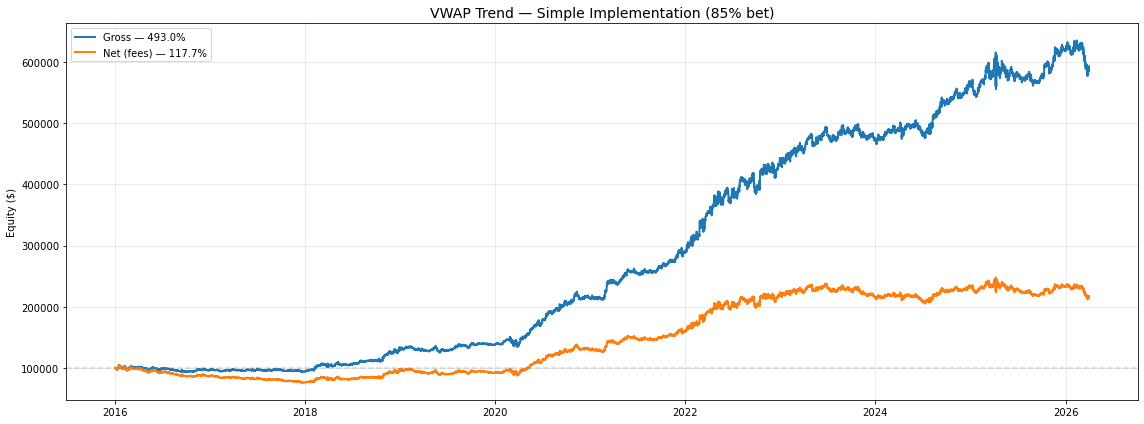

Fee drag: $375,339


In [13]:
BET_SIZE = 0.85

equity_gross = STARTING_CAPITAL
equity_net = STARTING_CAPITAL
gross_curve = [STARTING_CAPITAL]
net_curve = [STARTING_CAPITAL]

for _, trade in raw_trades.iterrows():
    shares_g = int(equity_gross * BET_SIZE / trade["entry_price"])
    shares_n = int(equity_net * BET_SIZE / trade["entry_price"])

    if trade["direction"] == "long":
        pnl_g = shares_g * (trade["exit_price"] - trade["entry_price"])
        pnl_n = shares_n * (trade["exit_price"] - trade["entry_price"])
    else:
        pnl_g = shares_g * (trade["entry_price"] - trade["exit_price"])
        pnl_n = shares_n * (trade["entry_price"] - trade["exit_price"])

    from _shared.fees import calculate_fees
    fees = calculate_fees(shares_n, trade["entry_price"], trade["exit_price"], trade["direction"], slippage=0.0)

    equity_gross += pnl_g
    equity_net += pnl_n - fees
    gross_curve.append(equity_gross)
    net_curve.append(equity_net)

dates = [pd.Timestamp(START_DATE)] + pd.to_datetime(raw_trades["exit_time"]).tolist()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dates, gross_curve, linewidth=2, label=f"Gross — {(gross_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.plot(dates, net_curve, linewidth=2, label=f"Net (fees) — {(net_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Simple Implementation ({BET_SIZE:.0%} bet)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Fee drag: ${gross_curve[-1] - net_curve[-1]:,.0f}")

## 7. Save Standardized Trades

In [8]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv("results/vwap_trend_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades → results/vwap_trend_trades.csv")

summary = {
    "strategy":    STRATEGY_NAME,
    "instrument":  INSTRUMENT,
    "portfolio":   "short_term",
    "period":      f"{START_DATE} → {END_DATE}",
    "params":      {"first_trade": "9:31", "exit_time": "15:55"},
    "trades":      len(raw_trades),
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open("results/vwap_trend_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary → results/vwap_trend_summary.json")
print(f"\nNext: run VWAP_Trend_Implementation.ipynb for sizing comparison")

Saved 41289 standardized trades → results/vwap_trend_trades.csv
Saved summary → results/vwap_trend_summary.json

Next: run VWAP_Trend_Implementation.ipynb for sizing comparison
